# Phase Diagram of RAG Failure

**question:** Is there a critical distractor density n* above which model accuracy collapses sharply — and does n* differ by gold-passage position?



In [29]:
import asyncio, json, hashlib, random, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
from anthropic import AsyncAnthropic, RateLimitError
from dotenv import load_dotenv; load_dotenv("../../.env")

ac = AsyncAnthropic()
CACHE = Path(".cache/phase"); CACHE.mkdir(parents=True, exist_ok=True)

DENSITIES = [0, 1, 2, 3, 5, 7, 10, 15, 20]
POSITIONS = ["start", "middle", "end"]
MODEL     = "claude-haiku-4-5"

# All questions are about FICTIONAL entities — the model cannot answer from
# parametric memory and must read the passages to find the gold answer.
# Each distractor passage is the same sentence as the gold but with a wrong value,
# making it a genuine multi-answer conflict rather than vague epistemic noise.
QS = [
    dict(qid="q01", question="What is the population of Miredale?", gold="6,847",
         gold_passage="Miredale is a lakeside settlement with a recorded population of 6,847.",
         distractor_tmpl="Miredale is a lakeside settlement with a recorded population of {v}.",
         wrongs=["12,203","3,091","9,440","1,882","15,621","7,304","4,519","20,077",
                 "8,963","2,741","11,358","5,206","18,490","6,102","13,877",
                 "4,831","9,718","2,304","16,543","7,928"]),
    dict(qid="q02", question="In what year was the Halverton Institute founded?", gold="1923",
         gold_passage="The Halverton Institute was established in 1923 by a consortium of industrial benefactors.",
         distractor_tmpl="The Halverton Institute was established in {v} by a consortium of industrial benefactors.",
         wrongs=["1897","1912","1934","1901","1918","1946","1889","1927","1955","1908",
                 "1938","1882","1915","1950","1872","1930","1945","1895","1907","1936"]),
    dict(qid="q03", question="How many floors does the Creston Tower have?", gold="47",
         gold_passage="The Creston Tower, completed in 1988, stands at 47 floors above street level.",
         distractor_tmpl="The Creston Tower, completed in 1988, stands at {v} floors above street level.",
         wrongs=["32","58","41","63","29","54","38","71","25","49","66","35","52","44",
                 "78","27","60","33","57","42"]),
    dict(qid="q04", question="What is the melting point of veratite in Celsius?", gold="312",
         gold_passage="Veratite, a synthetic mineral compound, has a melting point of 312 degrees Celsius.",
         distractor_tmpl="Veratite, a synthetic mineral compound, has a melting point of {v} degrees Celsius.",
         wrongs=["287","341","265","398","318","273","356","302","421","258","374","294",
                 "339","281","413","307","268","347","291","362"]),
    dict(qid="q05", question="Who is the current director of the Orendal Observatory?", gold="Dr. Yael Meston",
         gold_passage="The Orendal Observatory has been directed by Dr. Yael Meston since 2018.",
         distractor_tmpl="The Orendal Observatory has been directed by {v} since 2018.",
         wrongs=["Dr. Petra Hallvard","Prof. Soren Ikeda","Dr. Amara Nwachukwu","Prof. Lena Vogt",
                 "Dr. Cian Oduya","Prof. Hanna Brauer","Dr. Mikael Strand","Prof. Zara Achebe",
                 "Dr. Rolf Lindgren","Prof. Chioma Eze","Dr. Bente Solberg","Prof. Taini Kato",
                 "Dr. Olav Fjelstad","Prof. Nadia Ferreira","Dr. Sven Molstad",
                 "Prof. Amina Hassan","Dr. Lars Bekele","Prof. Ingrid Osei",
                 "Dr. Bjorn Nakamura","Prof. Fatou Lindqvist"]),
    dict(qid="q06", question="How many species does the Thornberry Wetlands host?", gold="214",
         gold_passage="The Thornberry Wetlands nature reserve is home to 214 documented species.",
         distractor_tmpl="The Thornberry Wetlands nature reserve is home to {v} documented species.",
         wrongs=["178","309","143","267","92","341","188","253","127","298","164","232",
                 "87","312","201","156","279","118","344","197"]),
    dict(qid="q07", question="What is the maximum depth of Lake Vorenka in meters?", gold="89",
         gold_passage="Lake Vorenka reaches a maximum depth of 89 meters at its northern basin.",
         distractor_tmpl="Lake Vorenka reaches a maximum depth of {v} meters at its northern basin.",
         wrongs=["54","127","73","102","38","148","61","93","44","118","67","84","31",
                 "156","79","112","46","138","58","97"]),
    dict(qid="q08", question="In what year did the Calwick Bridge collapse?", gold="1971",
         gold_passage="The Calwick Bridge suffered a catastrophic structural failure and collapsed in 1971.",
         distractor_tmpl="The Calwick Bridge suffered a catastrophic structural failure and collapsed in {v}.",
         wrongs=["1958","1984","1963","1979","1947","1967","1991","1954","1976","1942",
                 "1988","1961","1974","1949","1982","1956","1969","1944","1986","1973"]),
    dict(qid="q09", question="How long is the Dunmore Trail in kilometers?", gold="34",
         gold_passage="The Dunmore Trail stretches for 34 kilometers through the highland plateau.",
         distractor_tmpl="The Dunmore Trail stretches for {v} kilometers through the highland plateau.",
         wrongs=["19","47","28","61","23","53","16","39","57","25","44","31","68","21",
                 "50","27","42","18","55","37"]),
    dict(qid="q10", question="What is the altitude of Mount Faldreth in meters?", gold="2,841",
         gold_passage="Mount Faldreth, the highest peak in the Voren range, rises to an altitude of 2,841 meters.",
         distractor_tmpl="Mount Faldreth, the highest peak in the Voren range, rises to an altitude of {v} meters.",
         wrongs=["3,204","2,117","3,876","1,983","2,659","4,012","2,394","3,541","1,748",
                 "3,087","2,512","4,231","1,867","3,319","2,074","3,762","2,283","4,108",
                 "1,934","3,456"]),
    dict(qid="q11", question="How many employees does Pellwright Industries have?", gold="3,200",
         gold_passage="Pellwright Industries currently employs a workforce of 3,200 across its three main facilities.",
         distractor_tmpl="Pellwright Industries currently employs a workforce of {v} across its three main facilities.",
         wrongs=["7,450","1,830","9,120","2,640","5,310","1,090","8,740","4,280","2,010",
                 "6,870","3,540","1,420","7,980","2,890","5,630","1,270","9,400","4,710",
                 "2,350","6,180"]),
    dict(qid="q12", question="In what year were the Ostwick Accords signed?", gold="1887",
         gold_passage="The Ostwick Accords, a landmark regional treaty, were formally signed in 1887.",
         distractor_tmpl="The Ostwick Accords, a landmark regional treaty, were formally signed in {v}.",
         wrongs=["1861","1904","1873","1918","1856","1898","1912","1869","1893","1907",
                 "1845","1879","1916","1852","1886","1901","1864","1895","1921","1877"]),
    dict(qid="q13", question="How many volumes does the Terndale Encyclopedia contain?", gold="28",
         gold_passage="The Terndale Encyclopedia, first published in 1934, comprises 28 volumes.",
         distractor_tmpl="The Terndale Encyclopedia, first published in 1934, comprises {v} volumes.",
         wrongs=["14","36","22","41","17","33","25","48","12","39","20","45","16","31",
                 "24","43","19","37","27","52"]),
    dict(qid="q14", question="What is the wingspan of the velvet skimmer in centimeters?", gold="7.3",
         gold_passage="The velvet skimmer, a rare dragonfly species, has a wingspan of 7.3 centimeters.",
         distractor_tmpl="The velvet skimmer, a rare dragonfly species, has a wingspan of {v} centimeters.",
         wrongs=["4.1","9.8","5.6","11.2","3.7","8.4","6.2","10.7","4.9","12.3","5.1",
                 "8.9","3.4","10.1","6.8","13.5","4.6","9.2","7.7","11.8"]),
    dict(qid="q15", question="How many days does the Mirvani Festival last?", gold="11",
         gold_passage="The Mirvani Festival is an annual cultural celebration lasting 11 days.",
         distractor_tmpl="The Mirvani Festival is an annual cultural celebration lasting {v} days.",
         wrongs=["5","17","8","21","3","14","7","19","4","16","6","23","9","13","2",
                 "18","10","25","12","15"]),
]

_TEMPLATE = """\
Read the passages below and answer the question using ONLY the information given.
Do not use outside knowledge. If the passages do not contain a clear answer, say "unknown".

{passages}

Question: {question}
Answer (one word or short phrase):"""

In [30]:
def make_prompt(q: dict, n: int, position: str) -> str:
    """
    Builds a RAG-style prompt with n wrong-value distractors and 1 gold passage.
    Distractor selection is seeded on (qid, n, position) for cache stability.
    """
    assert position in POSITIONS
    assert n <= len(q["wrongs"]), f"n={n} exceeds distractor pool ({len(q['wrongs'])})"

    rng = np.random.default_rng(seed=abs(hash((q["qid"], n, position))) % 2**32)
    wrong_vals = rng.choice(q["wrongs"], size=n, replace=False).tolist()
    distractors = [q["distractor_tmpl"].format(v=v) for v in wrong_vals]
    gold_p = q["gold_passage"]

    if position == "start":
        passages = [gold_p] + distractors
    elif position == "middle":
        mid = n // 2
        passages = distractors[:mid] + [gold_p] + distractors[mid:]
    elif position == "end":
        passages = distractors + [gold_p]

    passage_block = "\n\n".join(f"[Passage {i+1}]\n{p}" for i, p in enumerate(passages))
    return _TEMPLATE.format(passages=passage_block, question=q["question"])

# ── Sanity checks ─────────────────────────────────────────────────────────────
q_test  = QS[0]
p_start  = make_prompt(q_test, n=3, position="start")
p_middle = make_prompt(q_test, n=4, position="middle")
p_end    = make_prompt(q_test, n=3, position="end")

def _passages_block(p):
    return p[p.index("[Passage 1]"):p.index("\n\nQuestion:")]

gold_p = q_test["gold_passage"]
assert gold_p in p_start and gold_p in p_middle and gold_p in p_end,       "gold passage must appear in every prompt"
assert _passages_block(p_start).startswith("[Passage 1]\n" + gold_p),       "start: gold must be first passage"
assert not _passages_block(p_middle).startswith("[Passage 1]\n" + gold_p),  "middle: gold must not be first"
assert not _passages_block(p_middle).endswith(gold_p),                      "middle: gold must not be last"
assert _passages_block(p_end).endswith(gold_p),                             "end: gold must be last passage"
assert make_prompt(q_test, n=3, position="start") == p_start,               "deterministic"

def _label_passages(q, n, position):
    rng = np.random.default_rng(seed=abs(hash((q["qid"], n, position))) % 2**32)
    wrong_vals = rng.choice(q["wrongs"], size=n, replace=False).tolist()
    distractors = [q["distractor_tmpl"].format(v=v) for v in wrong_vals]
    gold_p = q["gold_passage"]
    labeled = []
    if position == "start":
        labeled.append(("GOLD", gold_p))
        for i, d in enumerate(distractors, 1):
            labeled.append((f"DISTRACTOR {i}", d))
    elif position == "middle":
        mid = n // 2
        for i, d in enumerate(distractors[:mid], 1):
            labeled.append((f"DISTRACTOR {i}", d))
        labeled.append(("GOLD", gold_p))
        for i, d in enumerate(distractors[mid:], mid + 1):
            labeled.append((f"DISTRACTOR {i}", d))
    elif position == "end":
        for i, d in enumerate(distractors, 1):
            labeled.append((f"DISTRACTOR {i}", d))
        labeled.append(("GOLD", gold_p))
    return labeled

q_ex = QS[0]
print(f"Example: '{q_ex['question']}'  |  gold answer: {q_ex['gold']!r}\n")

for pos in POSITIONS:
    n_ex = 3
    print(f"{'═'*68}")
    print(f"  position={pos!r}  |  n={n_ex} distractors")
    print(f"{'─'*68}")
    for tag, text in _label_passages(q_ex, n=n_ex, position=pos):
        marker = "✓ GOLD      " if tag == "GOLD" else f"✗ {tag:<11}"
        print(f"  [{marker}]  {text}")
    print(f"  [QUESTION    ]  {q_ex['question']}")
    print(f"  [MODEL OUTPUT]  ___  ← correct answer is {q_ex['gold']!r}")

print(f"\n{'═'*68}")
print("  RAW PROMPT sent to API  (position='end', n=3 — gold buried last)")
print(f"{'─'*68}")
print(p_end)
print(f"{'═'*68}")
print("\nAll prompt tests passed.")

Example: 'What is the population of Miredale?'  |  gold answer: '6,847'

════════════════════════════════════════════════════════════════════
  position='start'  |  n=3 distractors
────────────────────────────────────────────────────────────────────
  [✓ GOLD      ]  Miredale is a lakeside settlement with a recorded population of 6,847.
  [✗ DISTRACTOR 1]  Miredale is a lakeside settlement with a recorded population of 4,831.
  [✗ DISTRACTOR 2]  Miredale is a lakeside settlement with a recorded population of 7,304.
  [✗ DISTRACTOR 3]  Miredale is a lakeside settlement with a recorded population of 8,963.
  [QUESTION    ]  What is the population of Miredale?
  [MODEL OUTPUT]  ___  ← correct answer is '6,847'
════════════════════════════════════════════════════════════════════
  position='middle'  |  n=3 distractors
────────────────────────────────────────────────────────────────────
  [✗ DISTRACTOR 1]  Miredale is a lakeside settlement with a recorded population of 16,543.
  [✓ GOLD    

In [31]:
SEM = asyncio.Semaphore(4)

async def call_model(prompt: str) -> str:
    k = hashlib.sha256(f"{prompt}{MODEL}".encode()).hexdigest()[:16]
    path = CACHE / f"{k}.json"
    if path.exists():
        return json.loads(path.read_text())["text"]
    async with SEM:
        for attempt in range(6):
            try:
                r = await ac.messages.create(
                    model=MODEL, max_tokens=32, temperature=0,
                    messages=[{"role": "user", "content": prompt}],
                )
                text = r.content[0].text.strip()
                path.write_text(json.dumps({"text": text}))
                return text
            except RateLimitError:
                wait = (2 ** attempt) + random.uniform(0, 1)
                print(f"  [429] retry {attempt+1}/6 in {wait:.1f}s…")
                await asyncio.sleep(wait)
        raise RuntimeError("Gave up after 6 retries")

def is_correct(gold: str, response: str) -> bool:
    # Strip commas and punctuation before comparing so "6,847" matches "6847" etc.
    def norm(s):
        return re.sub(r"[^a-z0-9.]", "", s.lower().replace(",", ""))
    return norm(gold) in norm(response)

async def run_sweep():
    tasks = [(q, n, pos) for q in QS for n in DENSITIES for pos in POSITIONS]
    print(f"{len(tasks)} cells to evaluate  ({len(QS)} questions × {len(DENSITIES)} densities × {len(POSITIONS)} positions)")

    async def _one(q, n, pos):
        prompt = make_prompt(q, n, pos)
        ans    = await call_model(prompt)
        return {"qid": q["qid"], "n": n, "position": pos,
                "gold": q["gold"], "answer": ans, "correct": is_correct(q["gold"], ans)}

    return pd.DataFrame(await asyncio.gather(*[_one(*t) for t in tasks]))

df = await run_sweep()
print(f"Done: {len(df)} rows, {df.correct.mean():.2%} overall accuracy")
df.groupby(["position", "n"])["correct"].mean().unstack().round(2)

405 cells to evaluate  (15 questions × 9 densities × 3 positions)
Done: 405 rows, 47.16% overall accuracy


n,0,1,2,3,5,7,10,15,20
position,,,,,,,,,
end,1.0,0.87,0.73,0.40,0.07,0.0,0.00,0.0,0.0
middle,1.0,1.00,0.93,0.93,0.47,0.2,0.00,0.0,0.0
start,1.0,1.00,0.93,0.93,0.80,0.4,0.07,0.0,0.0


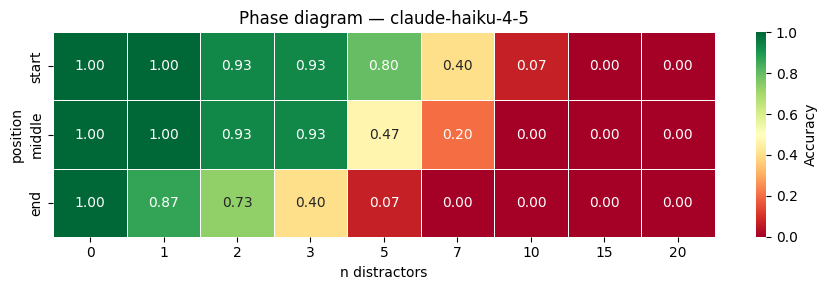

In [32]:
# Heatmap — provided scaffold
pivot = df.pivot_table(index="position", columns="n", values="correct", aggfunc="mean")
pivot = pivot.reindex(index=POSITIONS, columns=DENSITIES)

fig, ax = plt.subplots(figsize=(9, 3))
sns.heatmap(pivot, ax=ax, vmin=0, vmax=1, cmap="RdYlGn", annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"label": "Accuracy"})
ax.set_title(f"Phase diagram — {MODEL}")
ax.set_xlabel("n distractors")
plt.tight_layout()
plt.savefig("phase_diagram.png", dpi=150, bbox_inches="tight")
plt.show()

Position       n*        k  Sharp?
────────────────────────────────────────
start         6.6    0.803  sharp
middle        5.1    0.930  sharp
end           2.7    1.264  sharp


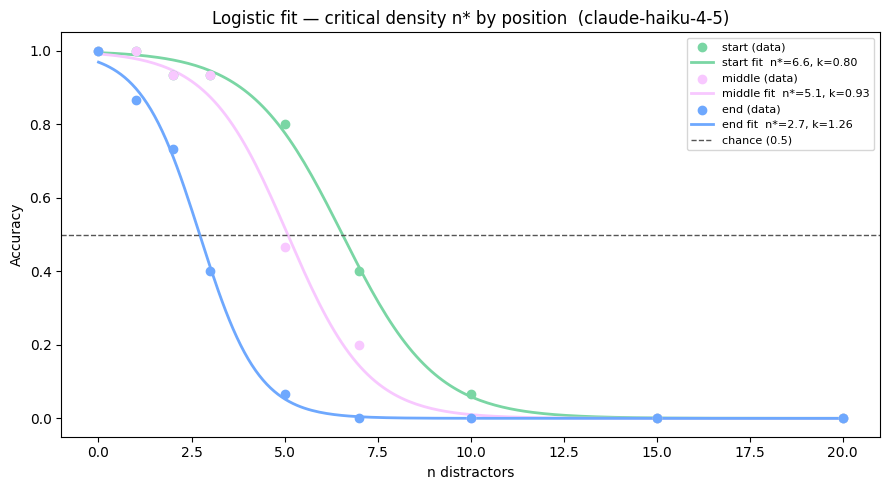


Position       R²
────────────────────
start       0.998
middle      0.994
end         0.998


In [34]:
from scipy.optimize import curve_fit

def logistic(x, k, n_star):
    # Acc(n) = 1 / (1 + exp(k*(n - n_star)))
    # k > 0 → accuracy falls as n rises; n_star is the inflection point (acc = 0.5)
    return 1.0 / (1.0 + np.exp(k * (x - n_star)))

fig, ax = plt.subplots(figsize=(9, 5))
colors = {"start": "#7ad6a4", "middle": "#f8c8ff", "end": "#6ea8fe"}

print(f"{'Position':<10} {'n*':>6} {'k':>8}  {'Sharp?'}")
print("─" * 40)

for pos in POSITIONS:
    pos_data = df[df["position"] == pos].groupby("n")["correct"].mean().reset_index()
    xdata = pos_data["n"].values.astype(float)
    ydata = pos_data["correct"].values.astype(float)

    # Plot raw accuracy points
    ax.scatter(xdata, ydata, color=colors[pos], zorder=3, label=f"{pos} (data)")

    try:
        # p0: k=0.3 (moderate slope), n_star=10 (midpoint of our range)
        # bounds: k must be positive (falling curve); n_star in [−2, 25]
        popt, _ = curve_fit(
            logistic, xdata, ydata,
            p0=[0.3, 10],
            bounds=([0.01, -2], [10.0, 25.0]),
            maxfev=10_000,
        )
        k, n_star = popt

        x_smooth = np.linspace(0, max(xdata), 200)
        ax.plot(x_smooth, logistic(x_smooth, k, n_star),
                color=colors[pos], linewidth=2, label=f"{pos} fit  n*={n_star:.1f}, k={k:.2f}")

        sharpness = "sharp" if k > 0.5 else "gradual"
        print(f"{pos:<10} {n_star:>6.1f} {k:>8.3f}  {sharpness}")

    except RuntimeError:
        # Fit didn't converge — data is probably too flat (model never really fails)
        print(f"{pos:<10}  fit did not converge (data too flat?)")
        ax.plot(xdata, ydata, color=colors[pos], linewidth=1.5,
                linestyle="--", label=f"{pos} (no fit)")

ax.axhline(0.5, color="#555", linestyle="--", linewidth=1, label="chance (0.5)")
ax.set_xlabel("n distractors")
ax.set_ylabel("Accuracy")
ax.set_title(f"Logistic fit — critical density n* by position  ({MODEL})")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("logistic_fit.png", dpi=150, bbox_inches="tight")
plt.show()

# note that sharper k means a more sudden drop in accuracy around n*; if k is small, the curve is more gradual and the model degrades more slowly as n increases
# position here is the position of the gold passage among the distractors; n* is the estimated number of distractors at which accuracy falls to 50%; k is the steepness of the drop in accuracy around n* (higher k means a sharper drop)


#getting R squred for the logistic fit
from sklearn.metrics import r2_score
print(f"\n{'Position':<10} {'R²':>6}")
print("─" * 20)
for pos in POSITIONS:
    pos_data = df[df["position"] == pos].groupby("n")["correct"].mean().reset_index()
    xdata = pos_data["n"].values.astype(float)
    ydata = pos_data["correct"].values.astype(float)

    try:
        popt, _ = curve_fit(
            logistic, xdata, ydata,
            p0=[0.3, 10],
            bounds=([0.01, -2], [10.0, 25.0]),
            maxfev=10_000,
        )
        k, n_star = popt
        y_pred = logistic(xdata, k, n_star)
        r2 = r2_score(ydata, y_pred)
        print(f"{pos:<10} {r2:>6.3f}")
    except RuntimeError:
        print(f"{pos:<10}  fit did not converge (data too flat?)")

## Key Findings

Overall the collapse tested on fictitious data ( which, it had to be, otherwise model simply relued on factual info if we were to ask it simple question like capital of Paris ) is quite sharp, and resembles a pahse shift. 
Start proves to be the most robust place, due to primacy bias - the model weight first info more. This is also supported by the fact that n* drops with position. 
R squared was also quite high - furtehr supporting the general idea. 

Though interesting to mention that this contradicts the loss in the middle idea. PRimarily due to the short nature of the passage / short contexts. 